# Inspecting Δ and |Δ| on real Jigsaw data

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from data.jigsaw import build_jigsaw_frame

In [3]:
# Load the Jigsaw dataset
df = pd.read_csv('../data/jigsaw/train.csv')
jf = build_jigsaw_frame(df)

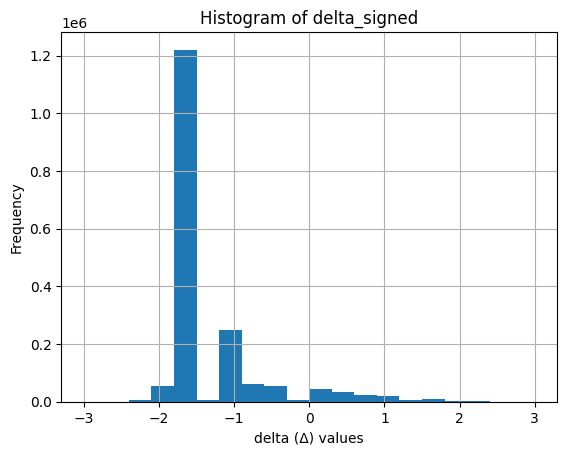

In [4]:
ax = jf["delta_signed"].hist(bins=20, range=(-3, 3))
ax.set_xlabel("delta (Δ) values")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of delta_signed")
plt.show()

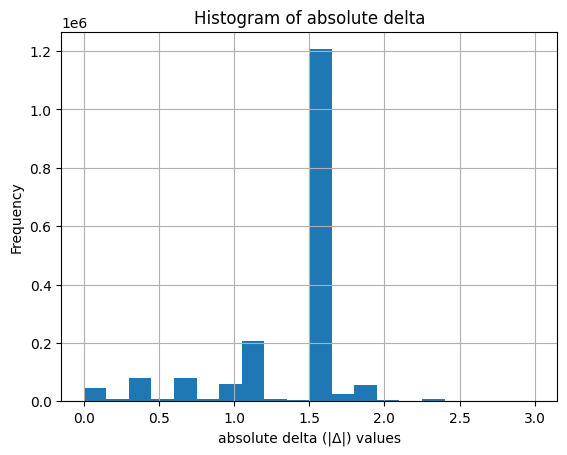

In [5]:
ax = jf["abs_delta"].hist(bins=20, range=(0, 3))
ax.set_xlabel("absolute delta (|Δ|) values")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of absolute delta")
plt.show()

# Inspecting delta patterns

In [6]:
# Calculate fraction of examples with |Δ| between 1 and 2
between_1_and_2 = ((jf["abs_delta"] >= 1) & (jf["abs_delta"] <= 2)).mean()
print(f"Fraction of examples with |Δ| between 1 and 2: {between_1_and_2:.4f}")

greater_2 = (jf["abs_delta"] > 2).mean()
print(f"Fraction of examples with |Δ| greater than 2: {greater_2:.4f}")

less_1 = (jf["abs_delta"] < 1).mean()
print(f"Fraction of examples with |Δ| less than 1: {less_1:.4f}")

mask = jf["abs_delta"].between(1, 2)
subset = jf.loc[mask, ["n_yes", "n_no"]]

# Small frequency table
freq = (
    subset
    .value_counts()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)

print(freq.head(20))

Fraction of examples with |Δ| between 1 and 2: 0.8358
Fraction of examples with |Δ| greater than 2: 0.0074
Fraction of examples with |Δ| less than 1: 0.1567
    n_yes  n_no    count
0       0     4  1182273
1       1     5   138400
2       2     8    53922
3       0     6    53317
4       0     5    21303
5       1     9    14534
6       8     2     5163
7       5     1     3445
8       1     6     3316
9       4     0     3016
10      1     8     1817
11      9     1     1472
12      6     0      675
13      5     0      370
14      1     7      334
15     53    17      275
16     52    18      274
18     60    20      248
17     59    21      248
19     54    16      238


In [11]:
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 1000)

# Examples with |Δ| < 1 (ambiguous-ish)
low_delta_examples = jf.loc[jf["abs_delta"] < 1, ["y_star", "comment_text"]].head(10)
print(f"Low Delta Examples:\n{low_delta_examples}")

# Examples with 1 ≤ |Δ| ≤ 2 (the big spike)
mid_delta_examples = jf.loc[jf["abs_delta"].between(1, 2), ["y_star", "comment_text"]].head(10)
print(f"Mid Delta Examples:\n{mid_delta_examples}")

# Examples with |Δ| > 2 (high-consensus)
high_delta_examples = jf.loc[jf["abs_delta"] > 2, ["y_star", "comment_text"]].head(10)
print(f"High Delta Examples:\n{high_delta_examples}")


Low Delta Examples:
    y_star                                                                                                                                                                                             comment_text
5        1                                                                                                                                                                                     ur a sh*tty comment.
6        0                                                                                                                                                                              hahahahahahahahhha suck it.
11       0                                                                                                  This is a great story. Man. I wonder if the person who yelled "shut the fuck up!" at him ever heard it.
13       1                                                                         It's ridiculous that these guys are being called 